# Setup

In [2]:
import numpy as np
from scipy.linalg import solve_continuous_are
from scipy.signal import lsim, StateSpace
import matplotlib.pyplot as plt

# Setup of system parameters
A  = np.array([[1., 1.],
               [1., 2.]])
B  = np.array([[1.],
               [0.]])
C  = np.array([[1., 0.]])

Rxx = np.eye(2)
Ruu = np.array([[0.01]])

def lqr(A, B, Q, R):
    """Solve CARE and return gain K and cost matrix P."""
    P = solve_continuous_are(A, B, Q, R)
    K = np.linalg.inv(R) @ B.T @ P
    return K, P

# Part a
LQR design + naive tracker u = r - Kx

In [3]:
K, P = lqr(A, B, Rxx, Ruu)
print(f"LQR gain K = {K}")
print(f"Closed-loop eigenvalues: {np.linalg.eigvals(A - B @ K)}")

# Closed-loop system: xdot = (A-BK)x + B*r,  y = Cx
Acl_a = A - B @ K
Bcl_a = B                    # naive: coefficient of r is just B
sys_a = StateSpace(Acl_a, Bcl_a, C, np.zeros((1,1)))

# Steady-state gain check
ss_gain_a = -C @ np.linalg.inv(Acl_a) @ B
print(f"\nDC gain (y_ss/r) = {ss_gain_a[0,0]:.4f}  should be 1 for perfect tracking")


LQR gain K = [[15.31933677 52.02170284]]
Closed-loop eigenvalues: [-10.10409298  -2.2152438 ]

DC gain (y_ss/r) = -0.0894  should be 1 for perfect tracking


# Part b
New design u = Nr - Kx

In [4]:
# Closed-loop system: xdot = (A-BK)x + B*N*r,  y = Cx
Acl_b = A - B @ K
# Choose N to ensure DC gain of 1
N = -1 / (C @ np.linalg.inv(Acl_b) @ B)
Bcl_b = N* B                    
sys_b = StateSpace(Acl_b, Bcl_b, C, np.zeros((1,1)))

# Steady-state gain check
ss_gain_b = -C @ np.linalg.inv(Acl_b) @ B * N
print(f"\nDC gain (y_ss/r) = {ss_gain_b[0,0]:.4f}  should be 1 for perfect tracking")



DC gain (y_ss/r) = 1.0000  should be 1 for perfect tracking


# Part c
LQ-servo with xi state for tracking error

In [9]:
# Augmented state: [x1, x2, xi]^T  (size 3)
#
#  [xdot ]   [  A   0 ] [x ]   [ B ] u + [0] r
#  [xidot] = [ -C   0 ] [xi] + [ 0 ]     [1]
#
#  y = [C  0] [x; xi]

n = A.shape[0]
A_aug = np.block([[A,           np.zeros((n, 1))],
                  [-C,          np.zeros((1, 1))]])
B_aug = np.block([[B],
                  [np.zeros((1, 1))]])
Br_aug = np.block([[np.zeros((n, 1))],
                   [np.ones((1, 1))]])         
C_aug = np.block([C, np.zeros((1, 1))])

# Weights: keep Rxx=I2, Ruu=0.01 for original states;
# tune xi weight qi to get similar performance to part (b)
qi = 50                 # tune this. higher = faster error correction
Q_aug = np.block([[Rxx,            np.zeros((n, 1))],
                  [np.zeros((1, n)), np.array([[qi]])]])

K_aug, _ = lqr(A_aug, B_aug, Q_aug, Ruu)
print(f"\nPart (c) augmented gain K_aug = {K_aug}")
print(f"  K (original states) = {K_aug[0, :n]}")
print(f"  Ki (integrator)     = {K_aug[0, n:]}")

# xdot_aug = (A_aug - B_aug K_aug) x_aug + Br_aug * r
Acl_c = A_aug - B_aug @ K_aug
sys_c = StateSpace(Acl_c, Br_aug, C_aug, np.zeros((1, 1)))

print(f"Closed-loop eigenvalues (aug): {np.linalg.eigvals(Acl_c)}")


Part (c) augmented gain K_aug = [[ 20.66074933 213.48321017  70.71067812]]
  K (original states) = [ 20.66074933 213.48321017]
  Ki (integrator)     = [70.71067812]
Closed-loop eigenvalues (aug): [-7.83988759+3.15055023j -7.83988759-3.15055023j -1.98097414+0.j        ]


# Simulation

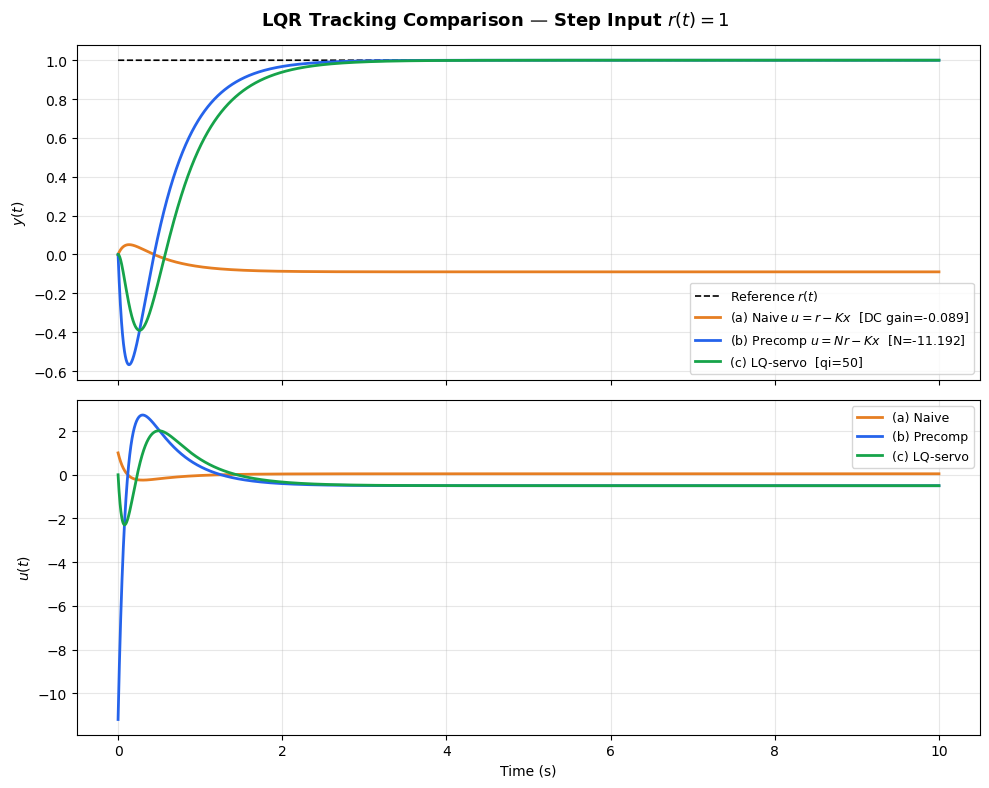


── Steady-state y values ──
  (a) Naive:   y_ss = -0.0894  (error = 1.0894)
  (b) Precomp: y_ss = 1.0000  (error = 0.0000)
  (c) LQ-servo: y_ss = 1.0000  (error = 0.0000)


In [13]:
t   = np.linspace(0, 10, 5000)
r   = np.ones_like(t)        # unit step at t=0
x0  = np.zeros(2)

_, y_a, _ = lsim(sys_a, r, t, X0=x0)
_, y_b, _ = lsim(sys_b, r, t, X0=x0)
_, y_c, _ = lsim(sys_c, r, t, X0=np.zeros(3))   # augmented: 3 states

# ── Control signal reconstruction (for plotting) ──────────────────────────────
def get_control_a(sys, r, t, x0, K, mode='naive', N=1):
    """Simulate and recover u(t)."""
    _, _, x = lsim(sys, r, t, X0=x0, return_x=True) if hasattr(lsim, 'return_x') else (None, None, None)
    # Use lsim with full output
    from scipy.signal import lsim
    tout, yout, xout = lsim(sys, r, t, X0=x0)
    if mode == 'naive':
        u = r - (K @ xout.T).flatten()
    elif mode == 'precomp':
        u = N * r - (K @ xout.T).flatten()
    return u

tout_a, y_a, xout_a = lsim(sys_a, r, t, X0=np.zeros(2))
tout_b, y_b, xout_b = lsim(sys_b, r, t, X0=np.zeros(2))
tout_c, y_c, xout_c = lsim(sys_c, r, t, X0=np.zeros(3))

u_a = (r   - (K     @ xout_a.T)).flatten()      # u = r - Kx
u_b = (N[0,0]*r - (K @ xout_b.T)).flatten()     # u = Nr - Kx
u_c = -(K_aug @ xout_c.T).flatten()             # u = -K_aug * x_aug (r already in state)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("LQR Tracking Comparison — Step Input $r(t)=1$",
             fontsize=13, fontweight='bold')

colors = {'a': '#e67e22', 'b': '#2563eb', 'c': '#16a34a'}

# Output y(t)
axes[0].plot(t, r,    'k--', lw=1.2, label='Reference $r(t)$')
axes[0].plot(t, y_a,  color=colors['a'], lw=2,
             label=f'(a) Naive $u=r-Kx$  [DC gain={ss_gain_a[0,0]:.3f}]')
axes[0].plot(t, y_b,  color=colors['b'], lw=2,
             label=f'(b) Precomp $u=Nr-Kx$  [N={N[0,0]:.3f}]')
axes[0].plot(t, y_c,  color=colors['c'], lw=2,
             label=f'(c) LQ-servo  [qi={qi}]')
axes[0].set_ylabel('$y(t)$'); axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)#; axes[0].set_ylim(-0.2, 1.5)

# Control u(t)
axes[1].plot(t, u_a, color=colors['a'], lw=2, label='(a) Naive')
axes[1].plot(t, u_b, color=colors['b'], lw=2, label='(b) Precomp')
axes[1].plot(t, u_c, color=colors['c'], lw=2, label='(c) LQ-servo')
axes[1].set_ylabel('$u(t)$'); axes[1].set_xlabel('Time (s)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lqr_tracking.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Steady-state summary ──────────────────────────────────────────────────────
print("\n── Steady-state y values ──")
print(f"  (a) Naive:   y_ss = {y_a[-1]:.4f}  (error = {1 - y_a[-1]:.4f})")
print(f"  (b) Precomp: y_ss = {y_b[-1]:.4f}  (error = {1 - y_b[-1]:.4f})")
print(f"  (c) LQ-servo: y_ss = {y_c[-1]:.4f}  (error = {1 - y_c[-1]:.4f})")


Part (c) augmented gain K_aug = [[  124.35303847 14628.55386203  7071.06781187]]
  K (original states) = [  124.35303847 14628.55386203]
  Ki (integrator)     = [7071.06781187]
Closed-loop eigenvalues (aug): [-59.67652013+59.24345576j -59.67652013-59.24345576j
  -1.99999822 +0.j        ]


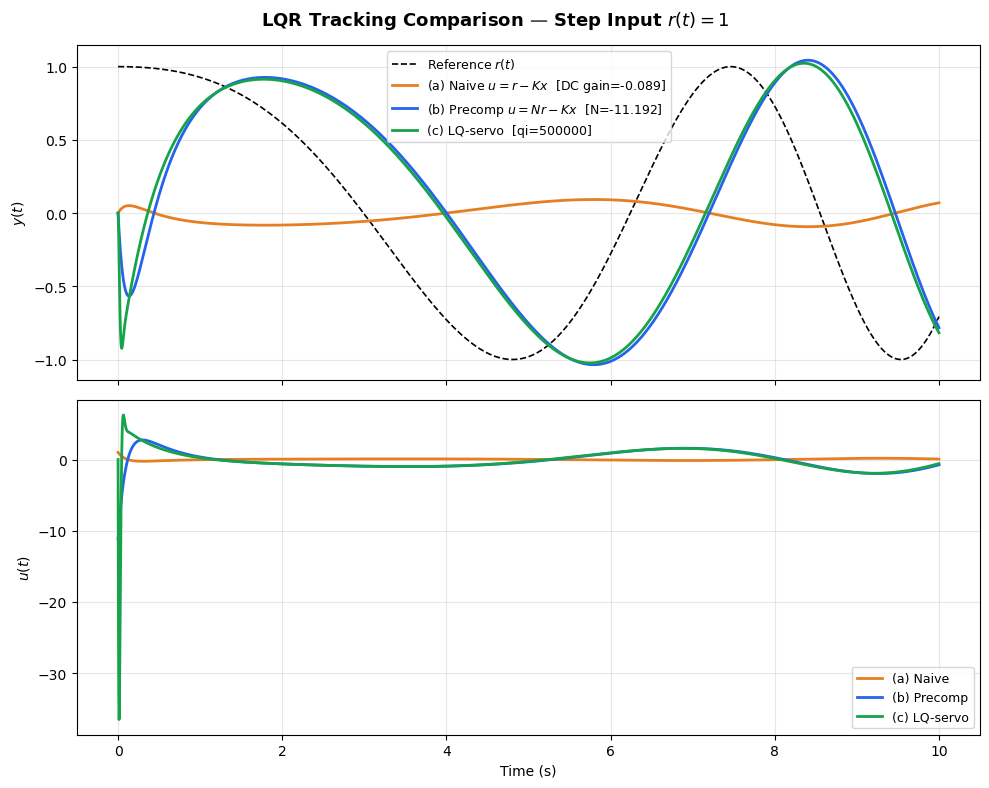


── Steady-state y values ──
  (a) Naive:   y_ss = 0.0700  (error = 0.9300)
  (b) Precomp: y_ss = -0.7832  (error = 1.7832)
  (c) LQ-servo: y_ss = -0.8175  (error = 1.8175)


In [18]:
from scipy.signal import chirp
# Augmented state: [x1, x2, xi]^T  (size 3)
#
#  [xdot ]   [  A   0 ] [x ]   [ B ] u + [0] r
#  [xidot] = [ -C   0 ] [xi] + [ 0 ]     [1]
#
#  y = [C  0] [x; xi]

n = A.shape[0]
A_aug = np.block([[A,           np.zeros((n, 1))],
                  [-C,          np.zeros((1, 1))]])
B_aug = np.block([[B],
                  [np.zeros((1, 1))]])
Br_aug = np.block([[np.zeros((n, 1))],
                   [np.ones((1, 1))]])         
C_aug = np.block([C, np.zeros((1, 1))])

# Weights: keep Rxx=I2, Ruu=0.01 for original states;
# tune xi weight qi to get similar performance to part (b)
qi = 500000                 # tune this. higher = faster error correction
Q_aug = np.block([[Rxx,            np.zeros((n, 1))],
                  [np.zeros((1, n)), np.array([[qi]])]])

K_aug, _ = lqr(A_aug, B_aug, Q_aug, Ruu)
print(f"\nPart (c) augmented gain K_aug = {K_aug}")
print(f"  K (original states) = {K_aug[0, :n]}")
print(f"  Ki (integrator)     = {K_aug[0, n:]}")

# xdot_aug = (A_aug - B_aug K_aug) x_aug + Br_aug * r
Acl_c = A_aug - B_aug @ K_aug
sys_c = StateSpace(Acl_c, Br_aug, C_aug, np.zeros((1, 1)))

print(f"Closed-loop eigenvalues (aug): {np.linalg.eigvals(Acl_c)}")

t   = np.linspace(0, 10, 5000)
r   = chirp(t, f0=0.05, f1=0.5, t1=20, method='linear')
x0  = np.zeros(2)

_, y_a, _ = lsim(sys_a, r, t, X0=x0)
_, y_b, _ = lsim(sys_b, r, t, X0=x0)
_, y_c, _ = lsim(sys_c, r, t, X0=np.zeros(3))   # augmented: 3 states

# ── Control signal reconstruction (for plotting) ──────────────────────────────
def get_control_a(sys, r, t, x0, K, mode='naive', N=1):
    """Simulate and recover u(t)."""
    _, _, x = lsim(sys, r, t, X0=x0, return_x=True) if hasattr(lsim, 'return_x') else (None, None, None)
    # Use lsim with full output
    from scipy.signal import lsim
    tout, yout, xout = lsim(sys, r, t, X0=x0)
    if mode == 'naive':
        u = r - (K @ xout.T).flatten()
    elif mode == 'precomp':
        u = N * r - (K @ xout.T).flatten()
    return u

tout_a, y_a, xout_a = lsim(sys_a, r, t, X0=np.zeros(2))
tout_b, y_b, xout_b = lsim(sys_b, r, t, X0=np.zeros(2))
tout_c, y_c, xout_c = lsim(sys_c, r, t, X0=np.zeros(3))

u_a = (r   - (K     @ xout_a.T)).flatten()      # u = r - Kx
u_b = (N[0,0]*r - (K @ xout_b.T)).flatten()     # u = Nr - Kx
u_c = -(K_aug @ xout_c.T).flatten()             # u = -K_aug * x_aug (r already in state)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("LQR Tracking Comparison — Step Input $r(t)=1$",
             fontsize=13, fontweight='bold')

colors = {'a': '#e67e22', 'b': '#2563eb', 'c': '#16a34a'}

# Output y(t)
axes[0].plot(t, r,    'k--', lw=1.2, label='Reference $r(t)$')
axes[0].plot(t, y_a,  color=colors['a'], lw=2,
             label=f'(a) Naive $u=r-Kx$  [DC gain={ss_gain_a[0,0]:.3f}]')
axes[0].plot(t, y_b,  color=colors['b'], lw=2,
             label=f'(b) Precomp $u=Nr-Kx$  [N={N[0,0]:.3f}]')
axes[0].plot(t, y_c,  color=colors['c'], lw=2,
             label=f'(c) LQ-servo  [qi={qi}]')
axes[0].set_ylabel('$y(t)$'); axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)#; axes[0].set_ylim(-0.2, 1.5)

# Control u(t)
axes[1].plot(t, u_a, color=colors['a'], lw=2, label='(a) Naive')
axes[1].plot(t, u_b, color=colors['b'], lw=2, label='(b) Precomp')
axes[1].plot(t, u_c, color=colors['c'], lw=2, label='(c) LQ-servo')
axes[1].set_ylabel('$u(t)$'); axes[1].set_xlabel('Time (s)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lqr_tracking.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Steady-state summary ──────────────────────────────────────────────────────
print("\n── Steady-state y values ──")
print(f"  (a) Naive:   y_ss = {y_a[-1]:.4f}  (error = {1 - y_a[-1]:.4f})")
print(f"  (b) Precomp: y_ss = {y_b[-1]:.4f}  (error = {1 - y_b[-1]:.4f})")
print(f"  (c) LQ-servo: y_ss = {y_c[-1]:.4f}  (error = {1 - y_c[-1]:.4f})")